In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tikzplotlib
# toppath = '/mpc/homes/fische_r/network_drives/COELY/02_Electrochemestry_Matthieu/01_Results/13_3rd_Year_Data/2024_porousAEM/20250217_Data_Paper'
toppath = '/mpc/homes/fische_r/network_drives/COELY/02_Electrochemestry_Matthieu/01_Results/13_3rd_Year_Data/2024_porousAEM/20250223_Data_Paper'

# outpath = '/mpc/homes/fische_r/network_drives/COELY/02_Electrochemestry_Matthieu/01_Results/13_3rd_Year_Data/2024_porousAEM/20250217_Data_Paper'
outpath = toppath

In [2]:
os.listdir(toppath)

['punshed_Time.csv',
 'comm_Time.csv',
 'home_Time.csv',
 'micro serp 5bar Cs_Time.csv',
 'micro serp 5bar_Time.csv',
 'micro serp_Time.csv',
 'micro_Time.csv',
 'Potential.csv']

In [3]:
Commercial = pd.read_csv(os.path.join(toppath, 'comm_Time.csv'))
Custom = pd.read_csv(os.path.join(toppath, 'home_Time.csv'))
Macro = pd.read_csv(os.path.join(toppath, 'punshed_Time.csv'))
Micro = pd.read_csv(os.path.join(toppath, 'micro_Time.csv'))
Micro_serp = pd.read_csv(os.path.join(toppath, 'micro serp_Time.csv'))
Micro_serp_5bar = pd.read_csv(os.path.join(toppath, 'micro serp 5bar_Time.csv'))
Edata = {'commercial': Commercial, 'custom': Custom, 'macroporous': Macro, 'microporous': Micro, 'microporous serp.': Micro_serp, 'microporous serp 5bar': Micro_serp_5bar}

In [14]:
var_LUT = {
    'FE_CO': {'shortname': 'FE$_{CO}$', 'unit': '', 'name': 'CO Faradaic efficiency', 'filename': 'FE_CO'},
    'FE_H2': {'shortname': 'FE$_{H_2}$', 'unit': '', 'name': 'H$_2$ Faradaic efficiency', 'filename': 'FE_H2'},
    '<i>/mAcm^(-2)': {'shortname': 'I', 'unit': '[mA/cm²]', 'name': 'current density', 'filename': 'current_density'},
    'i_co': {'shortname': 'I$_{CO}$', 'unit': '[mA/cm²]', 'name': 'partial CO current density', 'filename': 'CO_current_density'},
    'i_h2': {'shortname': 'I$_{H_2}$', 'unit': '[mA/cm²]', 'name': 'partial H$_2$ current density', 'filename': 'H2_current_density'},
    'Vaisala DP': {'shortname': 'T$_{dp}$', 'unit': '[°C]', 'name': 'dew point', 'filename': 'dew_point'},
    # 'Vaisala RH': {'shortname': 'RH', 'unit': '[%]', 'name': 'relative humidity'},
    # 'RH': {'shortname': 'RH', 'unit': '[%]', 'name': 'relative humidity'},
    '<Ewe>/V': {'shortname': 'E', 'unit': '[V]', 'name': 'working electrode voltage', 'filename': 'voltage'}
}

In [15]:
def magnus_roche(T):
    pvap = p_vap = 610.94*np.exp(17.625*T/(T+243.04))
    return pvap

def dew_point_to_RH(data, Tref=50):
    psat = magnus_roche(Tref)
    pvap = magnus_roche(data)
    RH = pvap/psat*100
    return RH

In [22]:
def plot_variable(var, samp = 50):
    plt.figure()
    
    for key in Edata.keys():
        try:
            if var == 'RH':
                data = Edata[key]['Vaisala DP'][::samp]
                data = dew_point_to_RH(data)
            else:
                data = Edata[key][var][::samp]
            if var == 'FE_CO' or var == 'FE_H2':
                data[data>2] = 2
                data[data<-1] = -1
            plt.plot(Edata[key]['Time0'][::samp], data, label=key)
        except:
            print(key+' data missing')
    
    if var=='Vaisala DP':
        plt.axhline(40, color='k', linestyle='-', label= 'cell Temperature')
    plt.axvline(105, color='k', linestyle='-')
    plt.axvline(55, color='k', linestyle='-')
    plt.axvline(347, color='k', linestyle='-')
    plt.xlabel('time [min]')
    plt.ylabel(var_LUT[var]['shortname']+' '+var_LUT[var]['unit'])
    if var == 'FE_CO' or var == 'FE_H2':
        plt.ylim(0,1.2)
    # else:
    #     plt.ylim(0)
    plt.xlim(0,550)
    # plt.legend(loc='upper right')
    

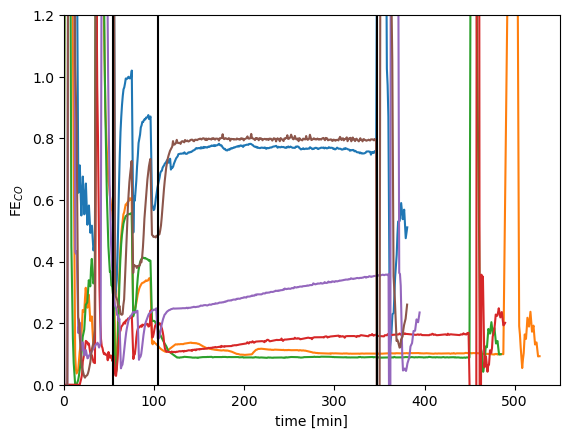

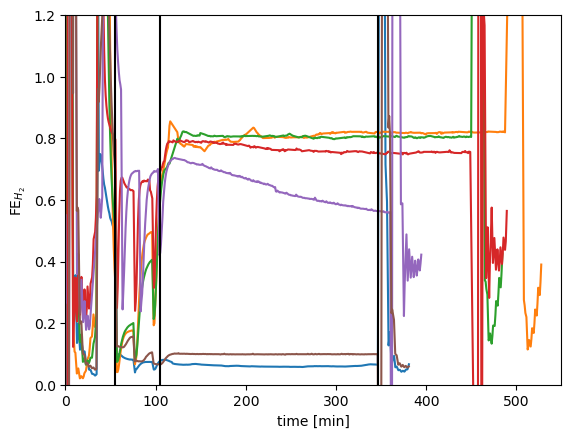

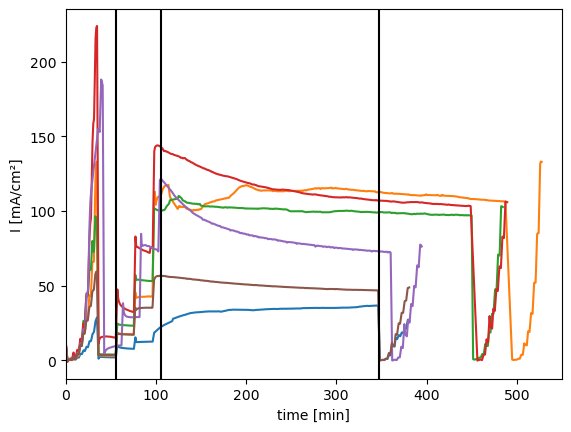

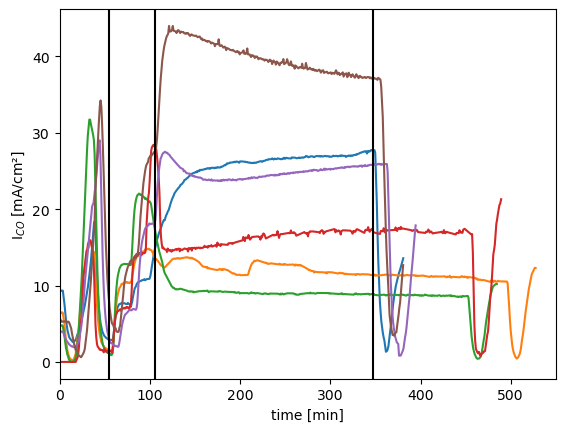

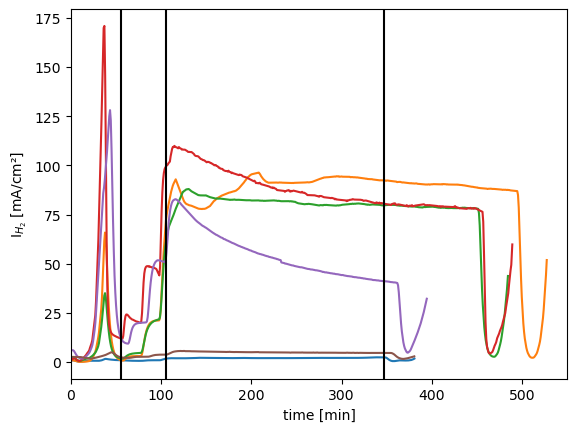

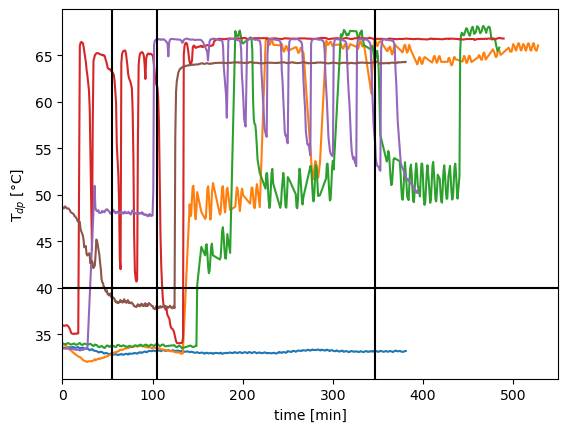

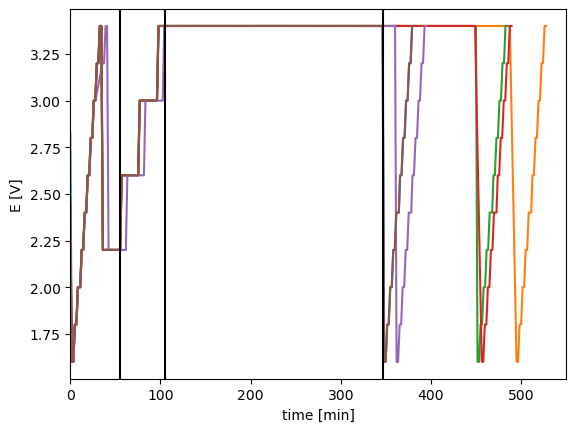

In [23]:
for var in var_LUT.keys():
    plot_variable(var)
    tikzplotlib.save(os.path.join(outpath, var_LUT[var]['filename']+'.tex'))

In [32]:
keys = list(Edata.keys())

In [20]:
keys

['commercial',
 'custom',
 'microporous',
 'microporous serp.',
 'microporous serp 5bar']

In [23]:
for d in Edata[keys[0]].keys():
    print(d)


Unnamed: 0
freq/Hz
Re(Z)/Ohm
-Im(Z)/Ohm
|Z|/Ohm
Phase(Z)/deg
time/s
<Ewe>/V
<I>/mA
Cs/µF
Cp/µF
cycle number
I Range
|Ewe|/V
|I|/A
Ns
(Q-Qo)/mA.h
<Ece>/V
|Ece|/V
Phase(Zce)/deg
|Zce|/Ohm
Re(Zce)/Ohm
-Im(Zce)/Ohm
Phase(Zwe-ce)/deg
|Zwe-ce|/Ohm
Re(Zwe-ce)/Ohm
-Im(Zwe-ce)/Ohm
THD Ewe/%
NSD Ewe/%
NSR Ewe/%
|Ewe h2|/V
|Ewe h3|/V
|Ewe h4|/V
|Ewe h5|/V
|Ewe h6|/V
|Ewe h7|/V
THD I/%
NSD I/%
NSR I/%
|I h2|/A
|I h3|/A
|I h4|/A
|I h5|/A
|I h6|/A
|I h7|/A
THD Ece/%
NSD Ece/%
NSR Ece/%
|Ece h2|/V
|Ece h3|/V
|Ece h4|/V
|Ece h5|/V
|Ece h6|/V
|Ece h7|/V
Re(Y)/Ohm-1
Im(Y)/Ohm-1
|Y|/Ohm-1
Phase(Y)/deg
Re(C)/nF
Im(C)/nF
|C|/nF
Phase(C)/deg
Re(M)
Im(M)
|M|
Phase(M)/deg
Re(Permittivity)
Im(Permittivity)
|Permittivity|
Phase(Permittivity)/deg
Re(Resistivity)/Ohm.cm
Im(Resistivity)/Ohm.cm
|Resistivity|/Ohm.cm
Phase(Resistivity)/deg
Re(Conductivity)/mS/cm
Im(Conductivity)/mS/cm
|Conductivity|/mS/cm
Phase(Conductivity)/deg
Tan(Delta)
Loss Angle(Delta)/deg
dq/mA.h
Unnamed: 80
<i>/mAcm^(-2)
Re(Z)/Ohmcm^2
-Im(Z)/O

In [24]:
from matplotlib import cm

In [25]:
test = np.arange(0,3.5,0.5)

In [26]:
test

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. ])

In [27]:
im = np.stack([test,test,test])

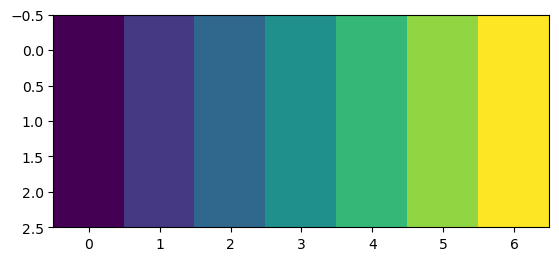

In [47]:
plt.imshow(im, cmap=cm.viridis)

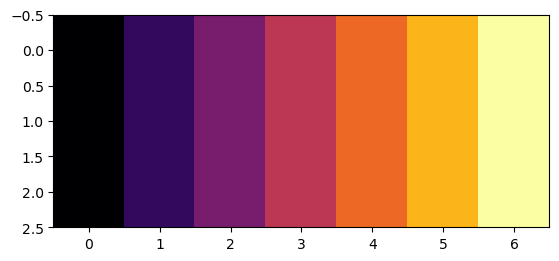

In [51]:
plt.imshow(im, cmap=cm.inferno)

In [53]:
(cm.inferno(test/3)*255).astype(int)

array([[  0,   0,   3, 255],
       [ 50,   9,  93, 255],
       [120,  28, 109, 255],
       [187,  55,  84, 255],
       [237, 104,  37, 255],
       [251, 181,  26, 255],
       [252, 254, 164, 255]])

In [35]:
cm.viridis(test/3*255)

array([[0.267004, 0.004874, 0.329415, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ]])